Four Methods to Detect Outliers:
1. Quantile Method
2. Standard Deviation Method
3. Z Score method
4. Interquartile Range Method

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm




  Quantile Method: Remove the most extreme outliers using the `[0.001, 0.999]` percentile range on the `Income` feature.

In [2]:
df=pd.read_csv('customer_profile.csv')

In [3]:
df.head()

,Age,Income,Spending_Score
0,39.967142,63892.663213,77.987109
1,33.617357,78641.249607,68.492674
2,41.476885,29021.486393,51.192607
3,50.230299,58444.538550,37.061264
4,32.658466,40240.361463,63.964466


In [4]:
df.describe()

,Age,Income,Spending_Score
count,504.000000,504.000000,504.000000
mean,35.047996,51376.380710,52.588979
std,10.264667,20605.775549,22.554853
min,-10.000000,5000.000000,-7.925108
25%,27.965428,41070.623902,37.887192
50%,35.127971,50438.757218,52.396117
75%,41.367833,59939.196163,65.179705
max,85.000000,300000.000000,250.000000


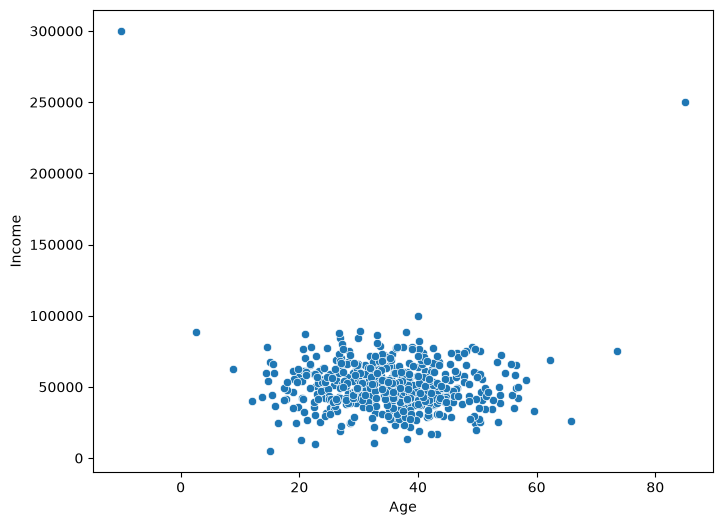

In [5]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x=df['Age'], y=df['Income'])
plt.show()

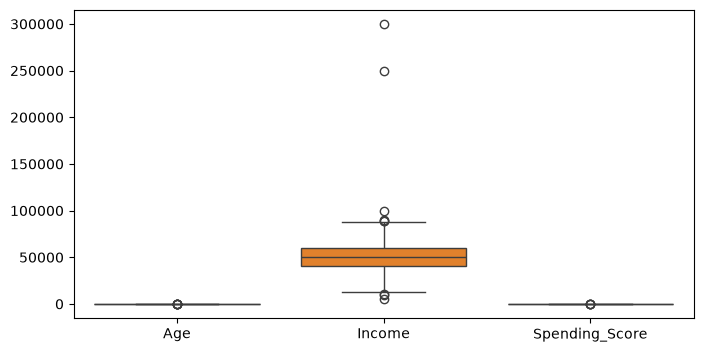

In [6]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df[['Age', 'Income', 'Spending_Score']])
plt.show()

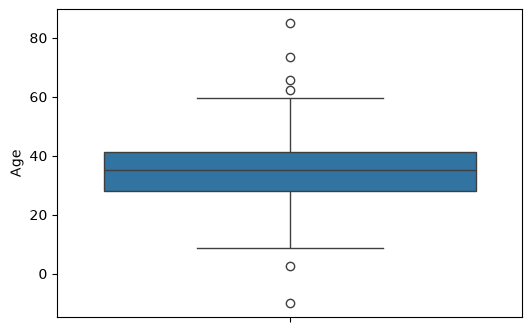

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, y='Age')
plt.show()

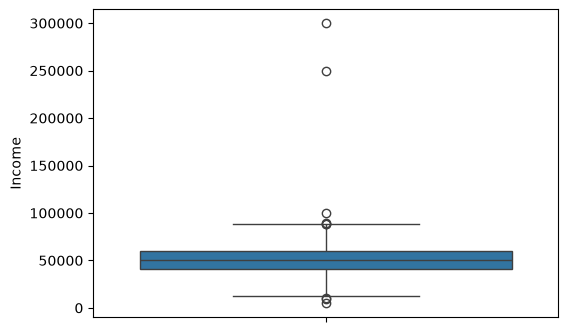

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, y='Income')
plt.show()

In [9]:
low_th = df['Income'].quantile(0.001)
upp_th = df['Income'].quantile(0.999)

In [10]:
outliers = df[(df['Income'] < low_th) | (df['Income'] > upp_th)]

In [11]:
outliers

,Age,Income,Spending_Score
501,15.0,5000.0,150.0
503,-10.0,300000.0,10.0


In [12]:
df_no_outliers = df[(df['Income'] >= low_th) & (df['Income'] <= upp_th)]

In [13]:
df_no_outliers

,Age,Income,Spending_Score
0,39.967142,63892.663213,77.987109
1,33.617357,78641.249607,68.492674
2,41.476885,29021.486393,51.192607
3,50.230299,58444.538550,37.061264
4,32.658466,40240.361463,63.964466
...,...,...,...
497,33.096613,59612.642919,74.167325
498,26.243817,41432.315153,70.481251
499,21.172003,58588.741720,61.850539
500,85.000000,250000.000000,10.000000


In [14]:
df_no_outliers.describe()

,Age,Income,Spending_Score
count,502.000000,502.000000,502.000000
mean,35.177669,50973.497765,52.479772
std,10.045615,17275.900873,22.094794
min,2.587327,9546.700356,-7.925108
25%,28.019785,41172.223842,37.908929
50%,35.170029,50438.757218,52.396117
75%,41.425117,59862.494279,65.150637
max,85.000000,250000.000000,250.000000


In [15]:
df.shape


(504, 3)

In [16]:
df_no_outliers.shape

(502, 3)

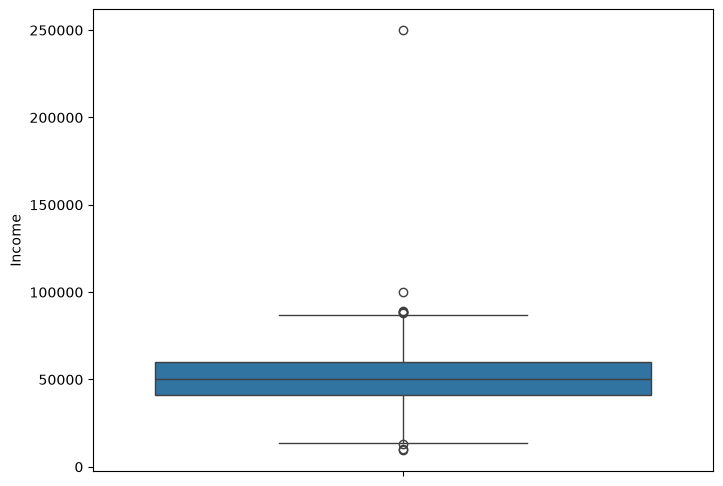

In [17]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df_no_outliers, y='Income')
plt.show()

2.  Standard Deviation Method: Apply the Standard Deviation method with a threshold of 3 on the `Spending_Score` feature.


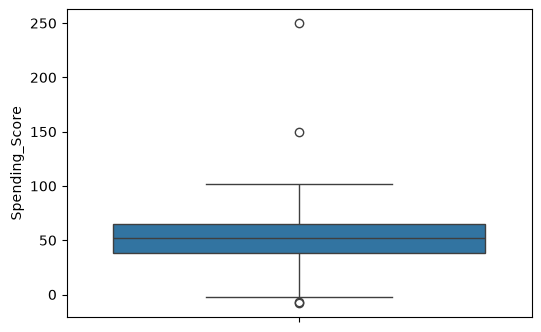

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, y='Spending_Score')
plt.show()

In [19]:
mean_score = df['Spending_Score'].mean()
std_score = df['Spending_Score'].std()

In [20]:
lower_limit = mean_score - 3 * std_score
upper_limit = mean_score + 3 * std_score

In [21]:
lower_limit

np.float64(-15.07557987447668)

In [22]:
upper_limit

np.float64(120.25353740782131)

In [23]:
outliers = df[(df['Spending_Score'] < lower_limit) | (df['Spending_Score'] > upper_limit)]

In [24]:
outliers

,Age,Income,Spending_Score
501,15.0,5000.0,150.0
502,40.0,100000.0,250.0


In [25]:
df_cleaned = df[(df['Spending_Score'] >= lower_limit) & (df['Spending_Score'] <= upper_limit)]

In [26]:
df_cleaned

,Age,Income,Spending_Score
0,39.967142,63892.663213,77.987109
1,33.617357,78641.249607,68.492674
2,41.476885,29021.486393,51.192607
3,50.230299,58444.538550,37.061264
4,32.658466,40240.361463,63.964466
...,...,...,...
497,33.096613,59612.642919,74.167325
498,26.243817,41432.315153,70.481251
499,21.172003,58588.741720,61.850539
500,85.000000,250000.000000,10.000000


In [27]:
df.shape

(504, 3)

In [28]:
df_cleaned.shape

(502, 3)

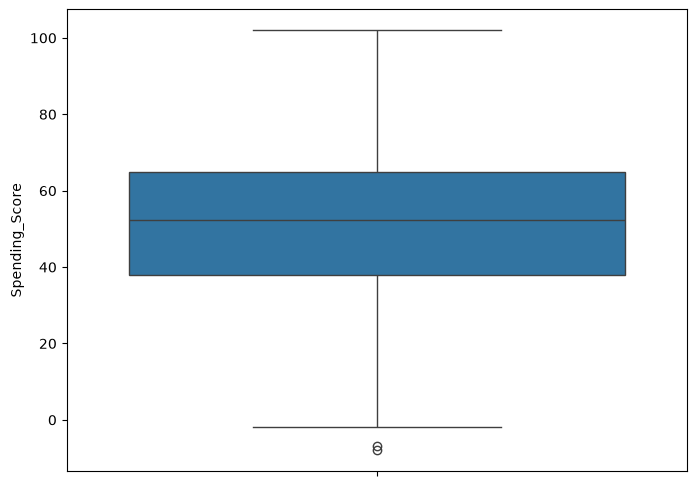

In [29]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df_cleaned, y='Spending_Score')
plt.show()

(array([0.00072465, 0.00108697, 0.00072465, 0.00289859, 0.0047102 ,
        0.00724647, 0.0108697 , 0.00942041, 0.0170292 , 0.01739152,
        0.02065243, 0.01956546, 0.02029011, 0.012319  , 0.01304364,
        0.00760879, 0.00797112, 0.00144929, 0.0047102 , 0.00217394]),
 array([ -7.92510756,  -2.42716907,   3.07076942,   8.56870791,
         14.06664641,  19.5645849 ,  25.06252339,  30.56046188,
         36.05840038,  41.55633887,  47.05427736,  52.55221585,
         58.05015434,  63.54809284,  69.04603133,  74.54396982,
         80.04190831,  85.53984681,  91.0377853 ,  96.53572379,
        102.03366228]),
 <BarContainer object of 20 artists>)

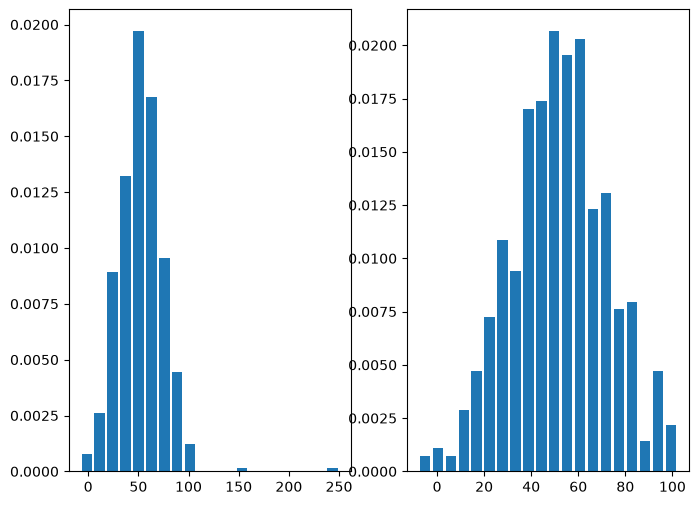

In [30]:
plt.figure(figsize=(8,6))

plt.subplot(1,2,1)
plt.hist(df['Spending_Score'], bins=20, rwidth=0.8, density=True)


#cleaned data

plt.subplot(1,2,2)
plt.hist(df_cleaned['Spending_Score'], bins=20, rwidth=0.8, density=True)


3.  Z-Score Method (Manual): Calculate Z-scores manually and use a threshold of `|Z| > 3` to remove outliers from the `Age` feature.

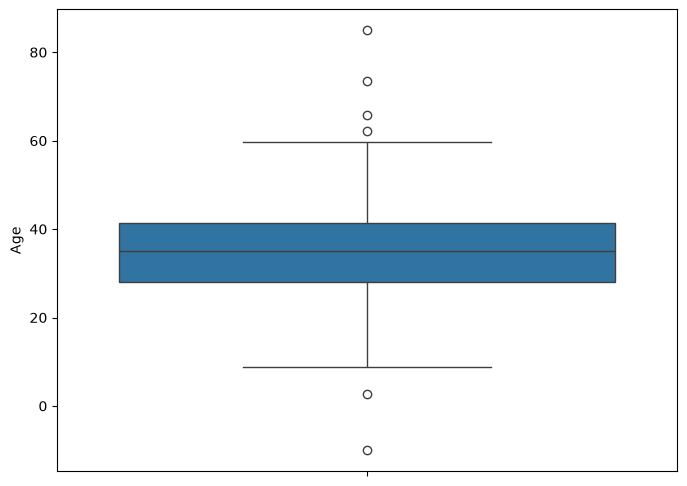

In [53]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='Age')
plt.show()

In [32]:
df['z_score'] = (df.Age - df.Age.mean()) / df.Age.std()

In [33]:
df

,Age,Income,Spending_Score,z_score
0,39.967142,63892.663213,77.987109,0.479231
1,33.617357,78641.249607,68.492674,-0.139375
2,41.476885,29021.486393,51.192607,0.626312
3,50.230299,58444.538550,37.061264,1.479084
4,32.658466,40240.361463,63.964466,-0.232792
...,...,...,...,...
499,21.172003,58588.741720,61.850539,-1.351821
500,85.000000,250000.000000,10.000000,4.866403
501,15.000000,5000.000000,150.000000,-1.953107
502,40.000000,100000.000000,250.000000,0.482432


In [47]:
outliers_zscore = df[(df['z_score']>3) | df['z_score']<-3]

In [48]:
outliers_zscore

,Age,Income,Spending_Score,z_score


In [49]:
df_no_outlier = df[(df['z_score']<3) | df['z_score']>-3]

In [50]:
df_no_outliers

,Age,Income,Spending_Score
0,39.967142,63892.663213,77.987109
1,33.617357,78641.249607,68.492674
2,41.476885,29021.486393,51.192607
3,50.230299,58444.538550,37.061264
4,32.658466,40240.361463,63.964466
...,...,...,...
497,33.096613,59612.642919,74.167325
498,26.243817,41432.315153,70.481251
499,21.172003,58588.741720,61.850539
500,85.000000,250000.000000,10.000000


In [51]:
df.shape

(504, 4)

In [52]:
df_no_outliers.shape

(502, 3)

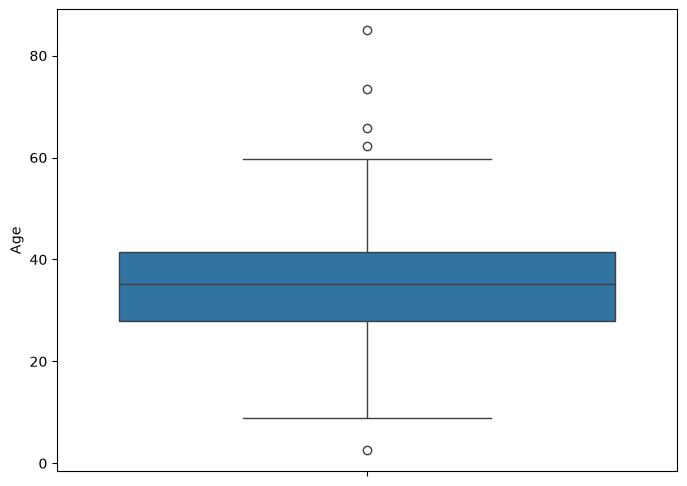

In [54]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df_no_outliers, y='Age')
plt.show()

4.  Interquartile Range (IQR) Method: Use the IQR method to identify and remove outliers from the `Income` feature.

In [55]:
df.head()

,Age,Income,Spending_Score,z_score
0,39.967142,63892.663213,77.987109,0.479231
1,33.617357,78641.249607,68.492674,-0.139375
2,41.476885,29021.486393,51.192607,0.626312
3,50.230299,58444.538550,37.061264,1.479084
4,32.658466,40240.361463,63.964466,-0.232792


<Axes: ylabel='Income'>

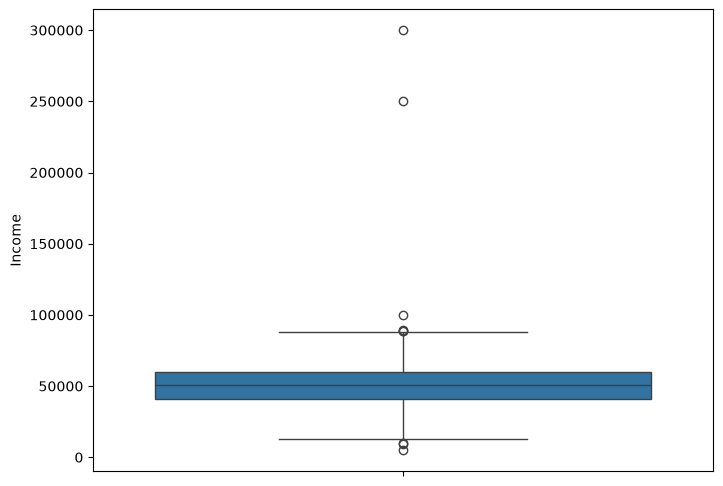

In [56]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='Income')

In [57]:
q1 = df['Income'].quantile(0.25)
q3 = df['Income'].quantile(0.75)
iqr = q3 - q1

In [58]:
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

In [60]:
lower_limit


np.float64(12767.765510529825)

In [61]:
upper_limit

np.float64(88242.05455479267)

In [62]:
outliers = df[(df['Income']<lower_limit) | (df['Income']>upper_limit)]

In [63]:
outliers

,Age,Income,Spending_Score,z_score
146,22.630493,9546.700356,28.074498,-1.209733
154,37.930725,88600.397049,82.840303,0.280840
168,32.546119,10235.452874,61.895087,-0.243737
255,30.157659,89485.730973,25.807180,-0.476424
262,2.587327,88401.268074,60.775120,-3.162369
500,85.000000,250000.000000,10.000000,4.866403
501,15.000000,5000.000000,150.000000,-1.953107
502,40.000000,100000.000000,250.000000,0.482432
503,-10.000000,300000.000000,10.000000,-4.388646


In [70]:
df_no_outliers = df[(df['Income']>=lower_limit) & (df['Income']<=upper_limit)]

In [71]:
df_no_outliers

,Age,Income,Spending_Score,z_score
0,39.967142,63892.663213,77.987109,0.479231
1,33.617357,78641.249607,68.492674,-0.139375
2,41.476885,29021.486393,51.192607,0.626312
3,50.230299,58444.538550,37.061264,1.479084
4,32.658466,40240.361463,63.964466,-0.232792
...,...,...,...,...
495,40.389100,45783.495607,90.121858,0.520339
496,24.627538,76965.297903,91.230072,-1.015177
497,33.096613,59612.642919,74.167325,-0.190107
498,26.243817,41432.315153,70.481251,-0.857717


In [72]:
df.shape

(504, 4)

In [73]:
df_no_outliers.shape

(495, 4)

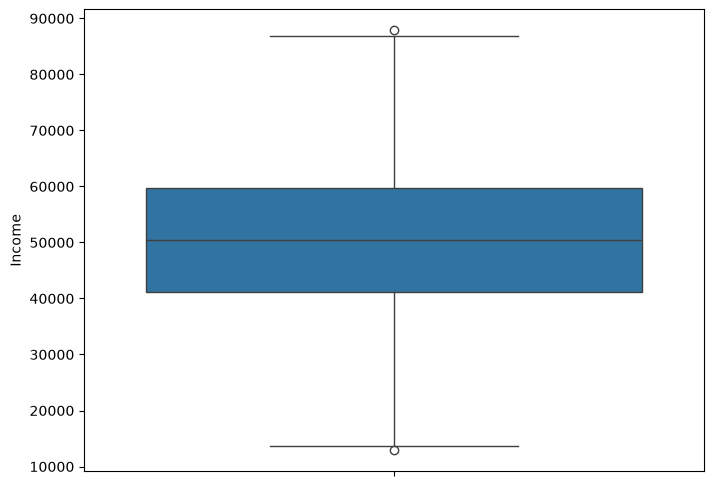

In [74]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df_no_outliers, y='Income')
plt.show()